# Pneumonia Detection using Hybrid CNN

This notebook implements a hybrid CNN model that combines a convolutional backbone with Squeeze-and-Excitation (SE) attention blocks to detect pneumonia from chest X-ray images.

**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) by Paul Mooney on Kaggle

**Approach:** CNN + SE Attention (hybrid) vs plain CNN baseline

**Classes:** NORMAL, PNEUMONIA

## 1. Setup and Imports

In [18]:

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_auc_score, roc_curve
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


## 2. Dataset Loading

The extracted dataset lives at `chest_xray/chest_xray/chest_xray/` relative to this notebook.
It has `train/` and `test/` splits. There is no separate `val/` folder, so we carve 20% out of training for validation.

In [19]:
DATA_DIR = r"C:\Users\joshu\Downloads\Projects\ML-CaPsule\Pneumonia Detection using Deep Learning\chest_xray\chest_xray"
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_dir = os.path.join(DATA_DIR, "train")
test_dir  = os.path.join(DATA_DIR, "test")

for split, path in [("train", train_dir), ("test", test_dir)]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        n = len(os.listdir(os.path.join(path, cls)))
        print(f"{split}/{cls}: {n} images")

train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images


## 3. Data Augmentation and Generators

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary",
    color_mode="rgb", subset="training", seed=42
)
val_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary",
    color_mode="rgb", subset="validation", shuffle=False, seed=42
)
test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary",
    color_mode="rgb", shuffle=False
)

print("Class indices:", train_gen.class_indices)
print(f"Train batches: {len(train_gen)}, Val batches: {len(val_gen)}, Test batches: {len(test_gen)}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches: 131, Val batches: 33, Test batches: 20


## 4. Visualise Sample Images

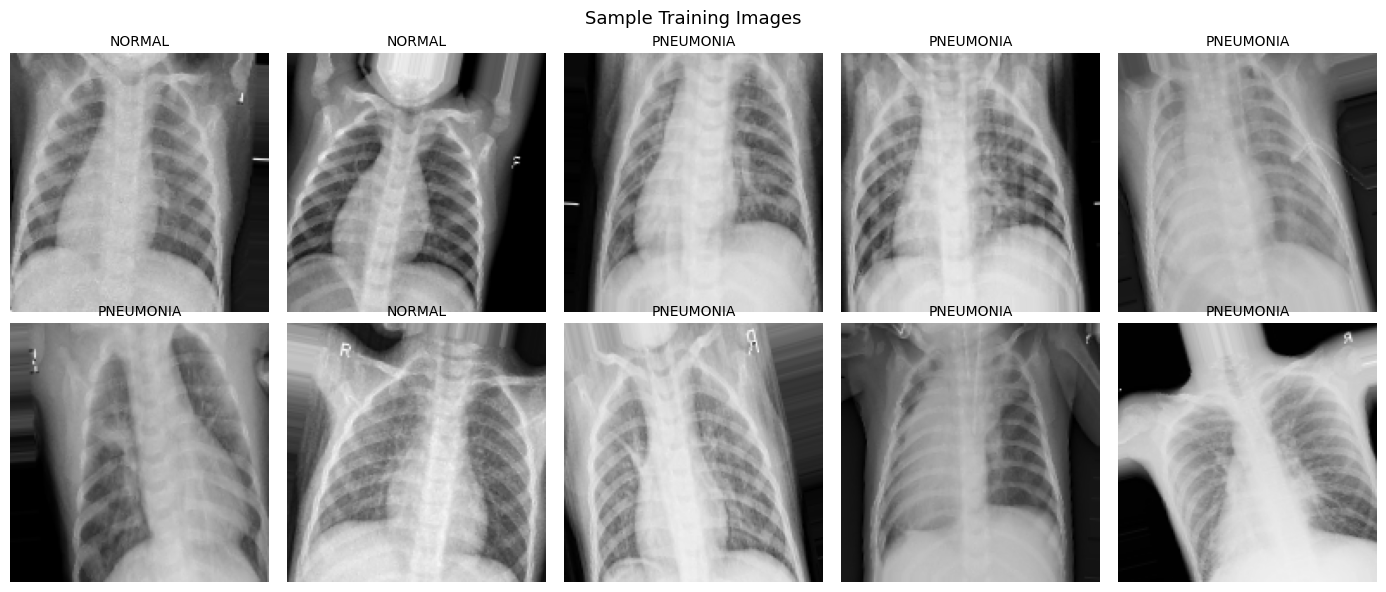

In [21]:
imgs, labels = next(train_gen)
class_names = ["NORMAL", "PNEUMONIA"]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    ax.set_title(class_names[int(labels[i])], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Model Architecture

### Squeeze-and-Excitation (SE) Block

An SE block recalibrates channel-wise feature responses by learning which channels matter most. It:
1. **Squeezes** spatial information with global average pooling
2. **Excites** by learning per-channel weights via two dense layers
3. **Scales** the original feature maps by those weights

Plugging SE blocks into a CNN makes it a **hybrid model** that combines spatial feature extraction with channel attention.

In [22]:
def se_block(x, ratio=8):
    """Squeeze-and-Excitation attention block."""
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // ratio, activation="relu")(se)
    se = layers.Dense(channels, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])


def build_hybrid_cnn(input_shape=(150, 150, 3)):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = se_block(x)
    x = layers.MaxPooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = se_block(x)
    x = layers.MaxPooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = se_block(x)
    x = layers.MaxPooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return Model(inputs, outputs, name="Hybrid_CNN_SE")


model = build_hybrid_cnn()
model.summary()

Model: "Hybrid_CNN_SE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 150, 150, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_12 (Conv2D)            │ (None, 150, 150, 32)      │             896 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_13 (Conv2D)            │ (None, 150, 150, 32)      │           9,248 │ conv2d_12[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_8    │ (None, 32)                │               0 │ conv2d_13[0][0]            │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_16 (Dense)              │ (None, 4)                 │             132 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_17 (Dense)              │ (None, 32)                │             160 │ dense_16[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_6 (Reshape)           │ (None, 1, 1, 32)          │               0 │ dense_17[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply_6 (Multiply)         │ (None, 150, 150, 32)      │               0 │ conv2d_13[0][0],           │
│                               │                           │                 │ reshape_6[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 75, 75, 32)        │               0 │ multiply_6[0][0]           │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 75, 75, 32)        │             128 │ max_pooling2d_6[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_8 (Dropout)           │ (None, 75, 75, 32)        │               0 │ batch_normalization_6[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_14 (Conv2D)            │ (None, 75, 75, 64)        │          18,496 │ dropout_8[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_15 (Conv2D)            │ (None, 75, 75, 64)        │          36,928 │ conv2d_14[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_9    │ (None, 64)                │               0 │ conv2d_15[0][0]            │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_18 (Dense)              │ (None, 8)                 │             52

 Total params: 326,813 (1.25 MB)

 Trainable params: 326,365 (1.24 MB)

 Non-trainable params: 448 (1.75 KB)

## 6. Compile and Train

In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor="val_loss", verbose=1)
]

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_gen.classes)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_gen.classes)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weight
)

Class weights: {np.int32(0): np.float64(1.9445479962721341), np.int32(1): np.float64(0.6730645161290323)}
Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.8301 - loss: 0.3497 - val_accuracy: 0.7430 - val_loss: 1.7404 - learning_rate: 0.0010
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.8871 - loss: 0.2532 - val_accuracy: 0.7430 - val_loss: 1.8342 - learning_rate: 0.0010
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.8991 - loss: 0.2224 - val_accuracy: 0.7430 - val_loss: 1.7712 - learning_rate: 0.0010
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.9075 - loss: 0.2146 - val_accuracy: 0.7526 - val_loss: 0.6027 - learning_rate: 0.0010
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.9279 - loss: 0.1826 - val_accuracy: 0.7430 - val_loss: 1.4257 - learning_rate: 0.0010
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.9360 - loss: 0.1548 - val_accuracy: 0.7430 - val_loss: 1.4952 

## 7. Training Curves

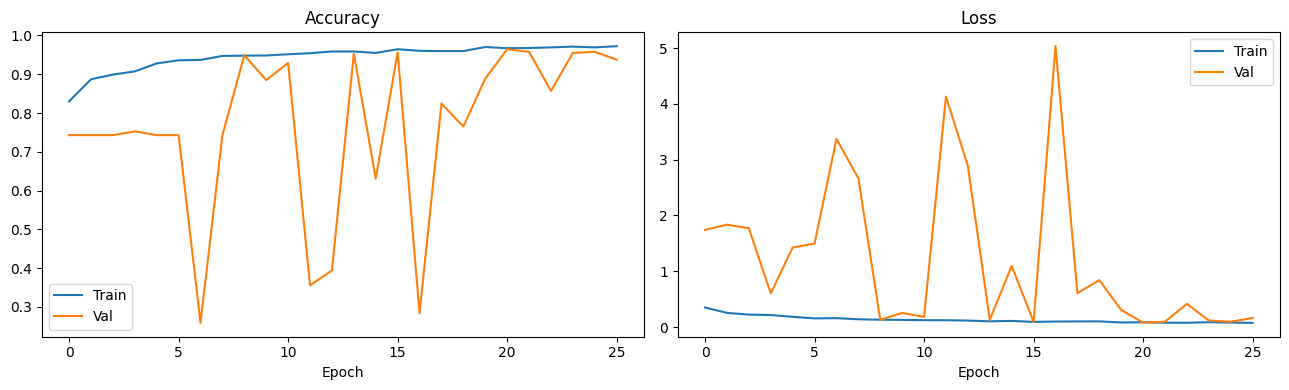

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

In [25]:
test_gen.reset()
y_prob = model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

print("Test Accuracy :", round(accuracy_score(y_true, y_pred), 4))
print("Test F1 Score :", round(f1_score(y_true, y_pred), 4))
print("Test ROC-AUC  :", round(roc_auc_score(y_true, y_prob), 4))
print()
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 572ms/step
Test Accuracy : 0.8526
Test F1 Score : 0.893
Test ROC-AUC  : 0.9547

              precision    recall  f1-score   support

      NORMAL       0.96      0.63      0.76       234
   PNEUMONIA       0.82      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.84       624



## 9. Confusion Matrix

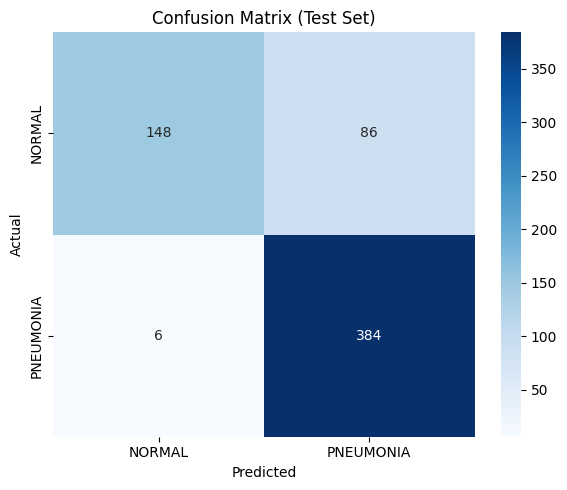

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

## 10. ROC Curve

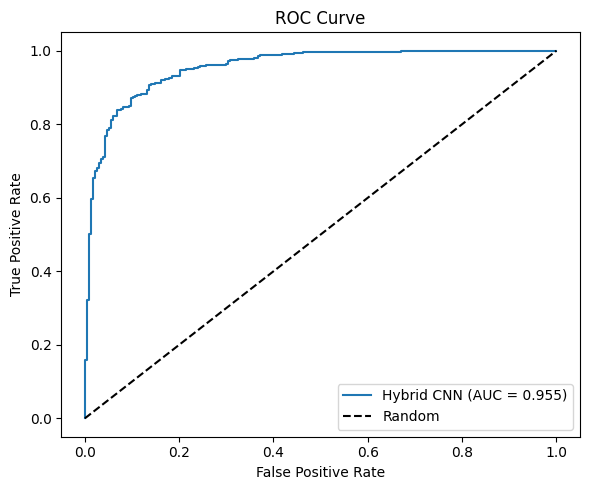

In [27]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Hybrid CNN (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Save the Model

In [28]:
model.save("hybrid_cnn_pneumonia.h5")
print("Model saved to hybrid_cnn_pneumonia.h5")

Model saved to hybrid_cnn_pneumonia.h5
